In [1]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

In [2]:
bk=pd.read_csv('Bonus_Midterm_data_setA.csv')

In [3]:
bk.shape

(10000, 14)

In [4]:
bk.head()

,ID,age,sex,ethnicity_group,education_college_university_0,townsend_deprivation_index,bmi_0,cholesterol_0,MET_activity,smoking_status_0,alcohol_status_0,dementia_all_outcome,MI_all_outcome,stroke_all_outcome
0,1405382,45,M,1,0,-1.604790,27.8376,6.483,4434.0,0,2,0,0,0
1,4951100,60,M,1,0,-3.030690,30.3461,5.657,7758.0,1,2,0,0,0
2,1905838,61,F,3,1,-0.494598,22.7585,4.382,1762.5,0,2,0,0,0
3,5789006,51,M,1,0,-2.666960,30.4153,4.489,2886.0,1,2,0,0,0
4,3446339,46,M,1,0,-0.109900,22.6736,6.061,2900.0,0,2,0,0,0


In [5]:
bk.dtypes

ID                                  int64
age                                 int64
sex                                object
ethnicity_group                     int64
education_college_university_0      int64
townsend_deprivation_index        float64
bmi_0                             float64
cholesterol_0                     float64
MET_activity                      float64
smoking_status_0                    int64
alcohol_status_0                    int64
dementia_all_outcome                int64
MI_all_outcome                      int64
stroke_all_outcome                  int64
dtype: object

In [6]:
bk.describe()

,ID,age,ethnicity_group,education_college_university_0,townsend_deprivation_index,bmi_0,cholesterol_0,MET_activity,smoking_status_0,alcohol_status_0,dementia_all_outcome,MI_all_outcome,stroke_all_outcome
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,3.504626e+06,56.295000,4.667000,0.338800,-1.407212,27.293288,5.697140,2640.81551,0.581600,1.889200,0.014400,0.053100,0.032300
std,1.461187e+06,8.130374,58.834181,0.473325,3.034013,4.727089,1.159595,2678.40509,0.811053,0.445357,0.119139,0.224244,0.176805
min,1.000012e+06,40.000000,1.000000,0.000000,-6.258260,12.646300,2.074000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.233048e+06,50.000000,1.000000,0.000000,-3.691205,24.052400,4.917000,780.00000,0.000000,2.000000,0.000000,0.000000,0.000000
50%,3.462561e+06,57.000000,1.000000,0.000000,-2.196720,26.624450,5.646500,1775.00000,0.000000,2.000000,0.000000,0.000000,0.000000
75%,4.780714e+06,63.000000,1.000000,1.000000,0.307542,29.617400,6.441000,3546.00000,1.000000,2.000000,0.000000,0.000000,0.000000
max,6.024512e+06,70.000000,999.000000,1.000000,9.892430,68.129900,10.748000,19278.00000,9.000000,9.000000,1.000000,1.000000,1.000000


In [7]:
bk.isna().sum()

ID                                0
age                               0
sex                               0
ethnicity_group                   0
education_college_university_0    0
townsend_deprivation_index        0
bmi_0                             0
cholesterol_0                     0
MET_activity                      0
smoking_status_0                  0
alcohol_status_0                  0
dementia_all_outcome              0
MI_all_outcome                    0
stroke_all_outcome                0
dtype: int64

In [8]:
bk_for_boxplot=bk.select_dtypes(include=[np.number])

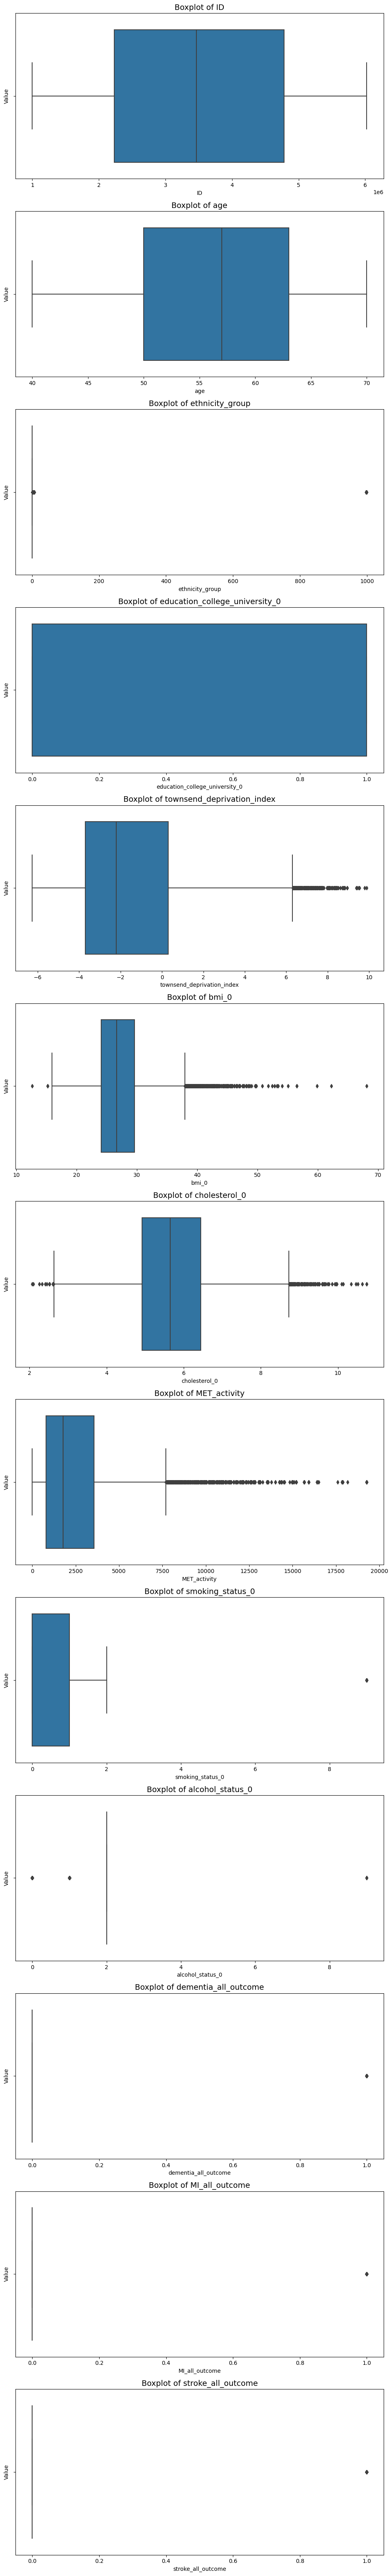

In [9]:
num_numeric_columns = bk_for_boxplot.shape[1]
fig, axes = plt.subplots(nrows=num_numeric_columns, ncols=1, figsize=(10, 5*num_numeric_columns))
if num_numeric_columns == 1:
    axes = [axes]

for i, col in enumerate(bk_for_boxplot.columns):
    sb.boxplot(x=bk_for_boxplot[col], ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}', fontsize=14)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Value')


plt.tight_layout()
plt.show()

In [10]:
bk['ethnicity_group'].unique()

array([  1,   3,   4,   6,   2,   5, 997, 999])

In [11]:
bk['ethnicity_group']=bk['ethnicity_group'].apply(lambda x: 6 if x>6 else x)

In [33]:
def desc_stat_analysis(df,col):
    variance = df[col].var()
    skewness = df[col].skew()
    kurtosis = df[col].kurtosis()

    print(f"\nStatistics for {col}:")
    print(f"Variance: {variance}")
    print(f"Skewness: {skewness}")
    print(f"Kurtosis: {kurtosis}")

# Project : Analysis of Risk Factors for Cardiovascular Diseases

**Statement**: Investigating the association between lifestyle factors (like smoking, alcohol consumption, physical activity) and the occurrence of cardiovascular diseases (like myocardial infarction and stroke).

**Research Question**: How do lifestyle factors contribute to the risk of developing cardiovascular diseases?

## First Step: Descriptive Statistics

**Details**: To understand the distribution and central tendency of folloing columns:[Age, Sex, BMI, Cholesterol, MET Activity, Smoking Status, Alcohol Status]. 

**Reason are following**:\
    **Age**: Since the Cardiovasular Diseases risk might increase with Age factor, so it's important to understand the distribution of the Age.\
    **SEX**: The Gender Differences in Cardiovascular Diseases have been discussed in many researches and papers and also been classified to the common factors for cardiovascular diseases, so understanding and analyzing the sex feature's distribution is also import for further analysis.\
    **BMI**: There're many well-documented researches on how BMI increases the risk of Cardiovascular Diseases, so descriptive analysis on the BMI feature will help to identify the health profile of the population under this study.\
    **Cholesterol**: High cholesterol levels are a major risk factor for heart disease and stroke. Understanding the distribution of cholesterol levels in this dataset can provide insights into the cardiovascular risk profile of the sample.\
    **MET Activity**: METs. MET stands for the metabolic equivalent of task. 1 MET is the amount of energy used while sitting quietly. Physical activities may be rated using METs to indicate their intensity. Meaning that higher MET activity reducing the risk of Cardiovascular Diseases and making it (MET activity) vital to be analysis under this topic.\
    **Smoking Status**: Well-known that Smoking is one of the leading factors for causing the Cardiovascular Diseases. So doing descriptive analysis on this feature can help understanding how prevalent this risk factor is in this study population.\
    **Alcohol Status**: Alcohol if excessive taking would increase the risk of Cardiovascualr Diseases. Putting this feature into the descriptive analysis can help understanding the lifestyle of this population.\

In [28]:
bk['age'].describe()

count    10000.000000
mean        56.295000
std          8.130374
min         40.000000
25%         50.000000
50%         57.000000
75%         63.000000
max         70.000000
Name: age, dtype: float64

**Mean**: The average age of individuals in the dataset is approximately 56.3 years. This indicates the distribution of the population of this dataset is around a middle-aged to older adult population.\
**Standard Deviation**: The standard deviation is about 8.13 years, suggesting that the ages in the dataset are spread out within an 8-year range on either side of the mean. This is a moderate level of variability.\
**Minimum and Maximum**: The ages range from 40 to 70 years. This restricted age range indicates that this dataset is specifically focused on middle-aged to senior individuals.\
**Quartiles**:
The 25th percentile is 50 years, meaning that 25% of individuals are younger than 50 years.\
The median (50th percentile) is 57 years, indicating that half of the individuals are younger than 57 years, and half are older.\
The 75th percentile is 63 years, meaning that 75% of individuals are younger than 63 years.

In [34]:
desc_stat_analysis(bk,'age')


Statistics for age:
Variance: 66.10298529852948
Skewness: -0.290955433382544
Kurtosis: -1.0372234269681415


**variance**: The variance is approximately 66.10, which further supports the standard deviation in indicating a moderate spread of age data.\
**Skewness**: The skewness value is approximately -0.29, suggesting a slight left skew in the age distribution. This means there are marginally more individuals in the dataset who are older than the mean age.\
**Kurtosis**: The kurtosis value is approximately -1.04, indicating a platykurtic distribution. This suggests that the ages are more uniformly spread out rather than being heavily concentrated around the mean. Additionally, there are fewer individuals who are significantly younger or older than the average compared to what you might see in a normal distribution.

**Summary**:
Overall, the age distribution in this dataset is centered around the mid-50s to early 60s, with a moderate spread and a slight skew towards older ages. The distribution is somewhat flat, with fewer extreme values (younger or older) than would be expected in a normal distribution.

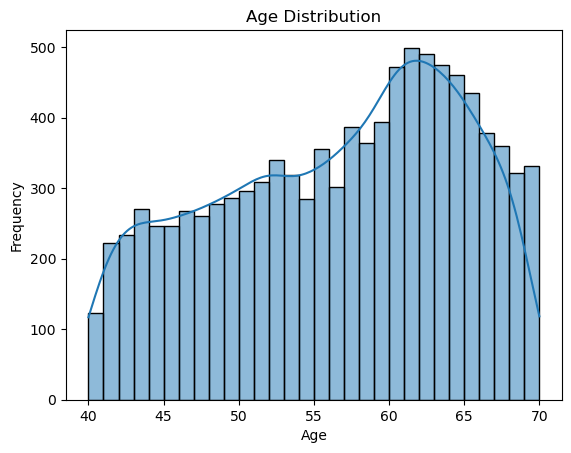

In [27]:
sb.histplot(bk['age'], kde=True, bins=30)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.show()

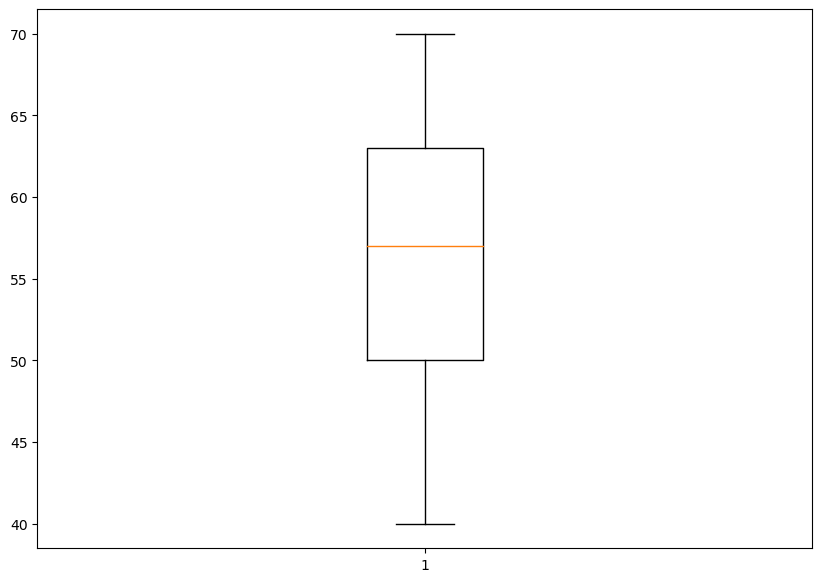

In [39]:
fig = plt.figure(figsize =(10, 7))
plt.boxplot(bk['age'])
plt.show()

In [36]:
bk['sex'].value_counts()

F    5262
M    4738
Name: sex, dtype: int64

In [37]:
bk['sex'].value_counts(normalize=True)

F    0.5262
M    0.4738
Name: sex, dtype: float64

**Summary**:
There 5262 female in the dataset and slightly more than half, while 4738 male in it and a bit less than half. The gender distribution of the dataset is in relative balance with a bit skew towards a higher female representation, suggesting that any gender-based analysis will have a fairly equal and representative sample from both genders.

<function matplotlib.pyplot.show(close=None, block=None)>

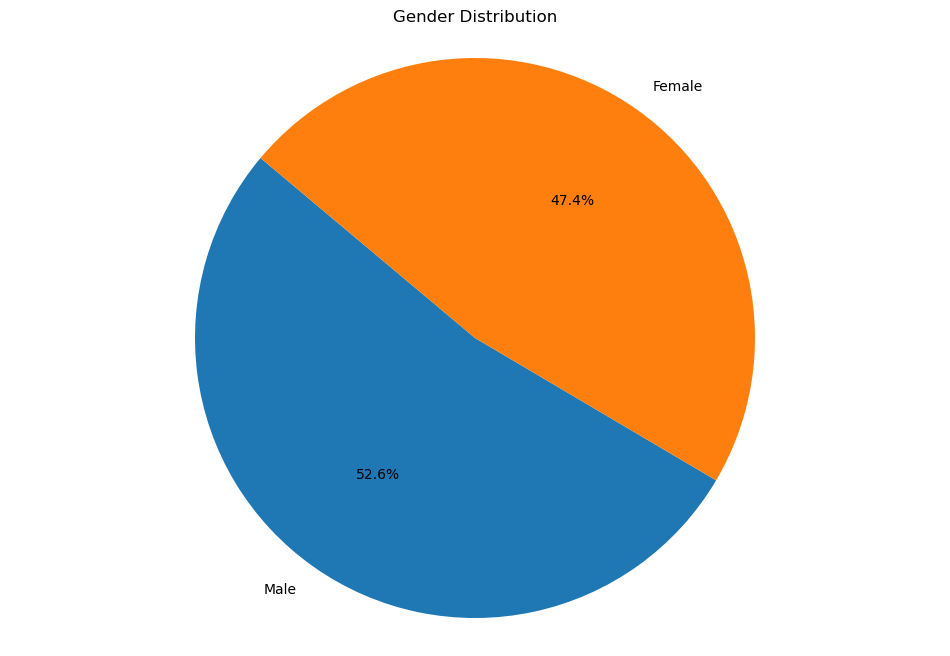

In [12]:
gender_count=bk['sex'].value_counts()
plt.figure(figsize=(12,8))
plt.pie(gender_count,labels=['Male','Female'],autopct='%1.1f%%', startangle=140)
plt.axis('equal')
plt.title('Gender Distribution')
plt.show

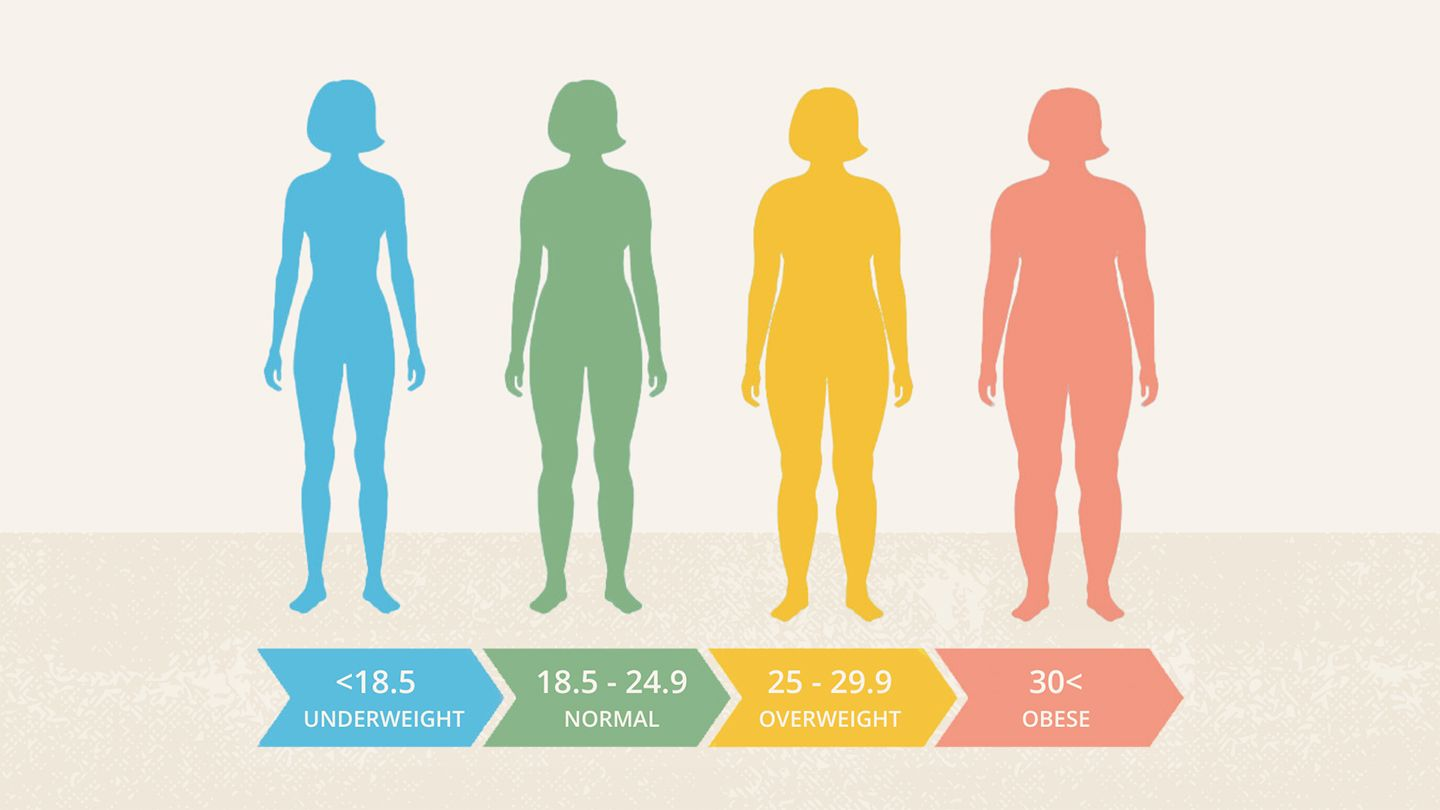

In [43]:
from IPython import display
display.Image("/Users/chungkaichou/Downloads/adult-body-mass-index-guide-alt-1440x810.jpg")

In [41]:
bk['bmi_0'].describe()

count    10000.000000
mean        27.293288
std          4.727089
min         12.646300
25%         24.052400
50%         26.624450
75%         29.617400
max         68.129900
Name: bmi_0, dtype: float64

**Mean**: The average BMI in the dataset is approximately 27.29. This is slightly above the upper limit of the 'normal weight' range and in the 'Overweight' range according to typical BMI classifications, indicating a trend towards overweight in the population.\
**Standard Deviation**: The standard deviation is about 4.73, suggesting a moderate variation in BMI among individuals, indicating a diverse range of body weight statuses from underweight to obese.\
**Minimum and Maximum**: The BMI values range from a minimum of 12.65 to a maximum of 68.13, showing the presence of extremely low (underweight) and extremely high (severe obesity) BMI values in the dataset.\
**Quartiles**:
The 25th percentile is 24.05, indicating that 25% of individuals have a BMI below this value, which falls within the 'normal weight' range.\
The median (50th percentile) is 26.62, suggesting that half of the individuals have a BMI below this value, which is in the range of 'Overweight'.\
The 75th percentile is 29.62, showing that 75% of individuals have a BMI below this value, which is in the 'overweight' category.

In [42]:
desc_stat_analysis(bk,'bmi_0')


Statistics for bmi_0:
Variance: 22.345366513644354
Skewness: 1.1978798174425644
Kurtosis: 3.2734451765741377


**Variance**:A variance of 22.35 suggests that individuals' BMIs vary moderately from the average. In other words, not everyone has a BMI close to the average; some have higher and some have lower BMIs, but these differences are not extremely large.\
**Skewness**:A skewness of 1.20 indicates that the BMI distribution is right-skewed or positively skewed. This means that more people in this dataset have a BMI higher than the average. In simpler terms, while most people have a BMI around the average, there is a notable number of individuals with a BMI significantly higher than the average, more so than those with a BMI significantly lower than the average.\
**Kurtosis**:A kurtosis of 3.27, which is higher than the standard 0 of a normal distribution, suggests a leptokurtic distribution. This means that this BMI distribution has a more pronounced peak and fatter tails. In simple terms, we have more people with BMIs near the average, and also a higher number of people with BMIs much higher or much lower than the average, compared to what we would expect in a perfectly bell-shaped curve.

**Summary**:
The BMI distribution in the dataset suggests a population that leans towards overweight, with a significant presence of individuals with higher BMI values. The distribution is right-skewed, indicating that extreme high BMI values are more common than extreme low values, and the presence of outliers is notable, as evidenced by the leptokurtic nature of the distribution.

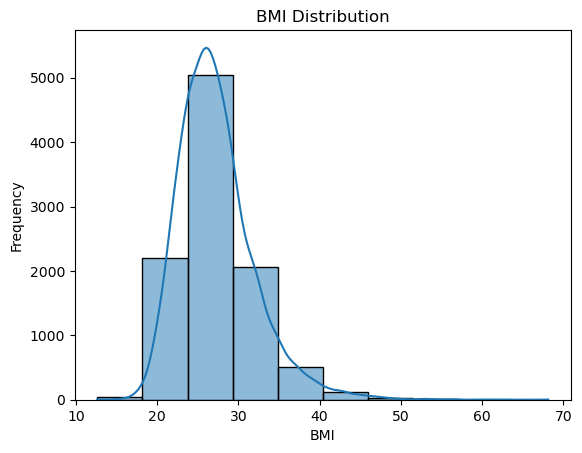

In [45]:
sb.histplot(bk['bmi_0'], kde=True, bins=10)
plt.title('BMI Distribution')
plt.xlabel('BMI')
plt.ylabel('Frequency')

plt.show()

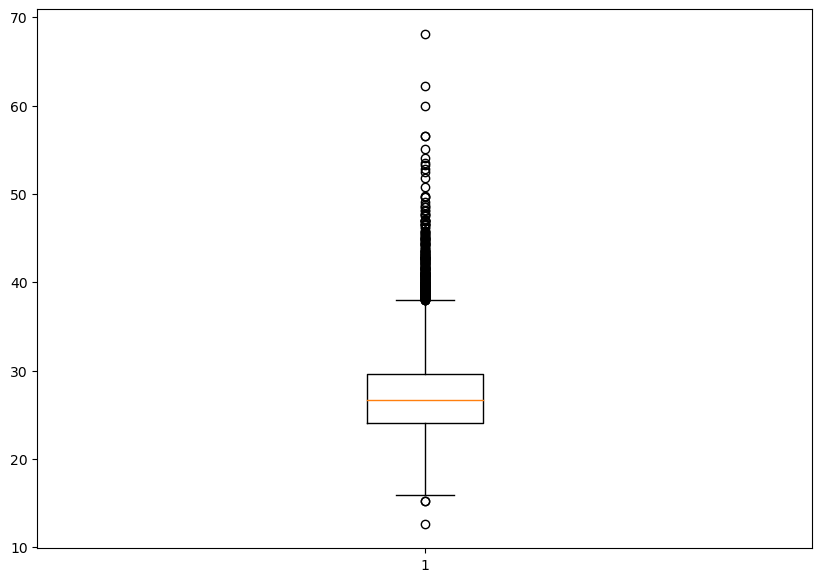

In [46]:
fig = plt.figure(figsize =(10, 7))
plt.boxplot(bk['bmi_0'])
plt.show()

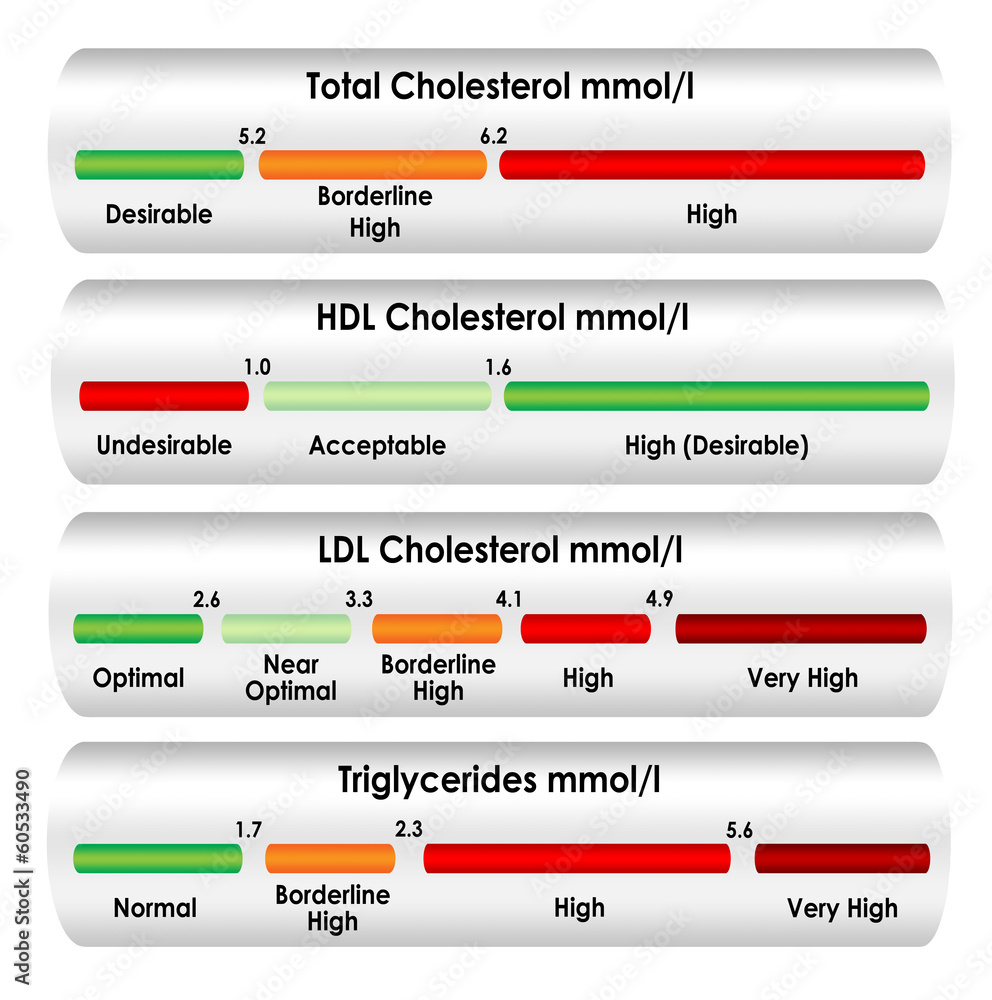

In [49]:
display.Image("/Users/chungkaichou/Downloads/1000_F_60533490_vFANIhr8jqkjrsipRilmZKnHpAW6BAXx.jpg")

In [47]:
bk['cholesterol_0'].describe()

count    10000.000000
mean         5.697140
std          1.159595
min          2.074000
25%          4.917000
50%          5.646500
75%          6.441000
max         10.748000
Name: cholesterol_0, dtype: float64

**Mean**: The average cholesterol level in the dataset is approximately 5.70. This figure can be contextualized based on typical cholesterol level guidelines, which generally consider levels between 5.2 to 6.2 mmol/L as borderline high.\
**Standard Deviation**: The standard deviation is about 1.16, indicating a moderate level of variability in cholesterol levels among individuals.\
**Minimum and Maximum**: The cholesterol levels range from a low of 2.07 to a high of 10.75. This wide range suggests the presence of both very low and very high cholesterol levels in the dataset.\
**Quartiles**:
The 25th percentile is 4.92, meaning 25% of individuals have cholesterol levels below this figure and in a desire range.\
The median (50th percentile) is 5.65, indicating that half of the individuals have cholesterol levels below this value and half above (in a bprderline high range). 
The 75th percentile is 6.44, showing that 25% of individuals have cholesterol levels above this value and is in high range.

In [48]:
desc_stat_analysis(bk,'cholesterol_0')


Statistics for cholesterol_0:
Variance: 1.3446598460964443
Skewness: 0.2754455369535128
Kurtosis: 0.2448423040135883


**Variance**: The variance is approximately 1.34, suggesting that the cholesterol levels of individuals are somewhat spread out, but not extremely so. In other words, while individuals' cholesterol levels vary, they don't vary wildly.\
**Skewness**: The skewness value is approximately 0.28 a low value, suggesting a slight right skew in the distribution. This means that there are somewhat more individuals with cholesterol levels higher than the mean compared to those with lower levels. However, this skewness is not very pronounced, so the distribution is still fairly symmetrical.\
**Kurtosis**: The kurtosis value is approximately 0.24, indicating a distribution that is close to normal (mesokurtic) in terms of its peak and tail heaviness. This suggests a balanced distribution with not too many extreme outliers.

**Summary**:
The cholesterol levels in this dataset show a moderate range with a slight tendency towards higher values. The distribution is relatively balanced, with a slight skew towards higher cholesterol levels but without extreme deviations from a normal distribution pattern.

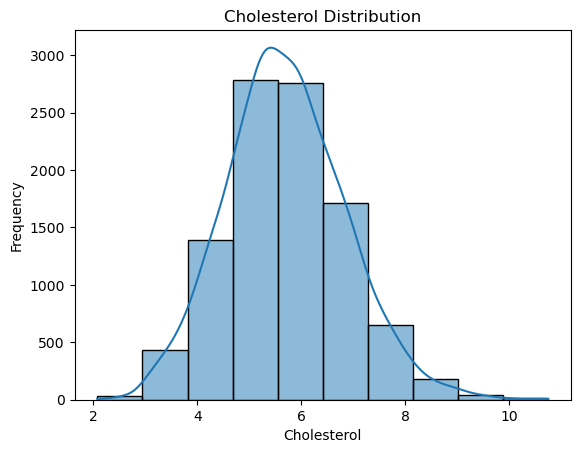

In [50]:
sb.histplot(bk['cholesterol_0'], kde=True, bins=10)
plt.title('Cholesterol Distribution')
plt.xlabel('Cholesterol')
plt.ylabel('Frequency')

plt.show()

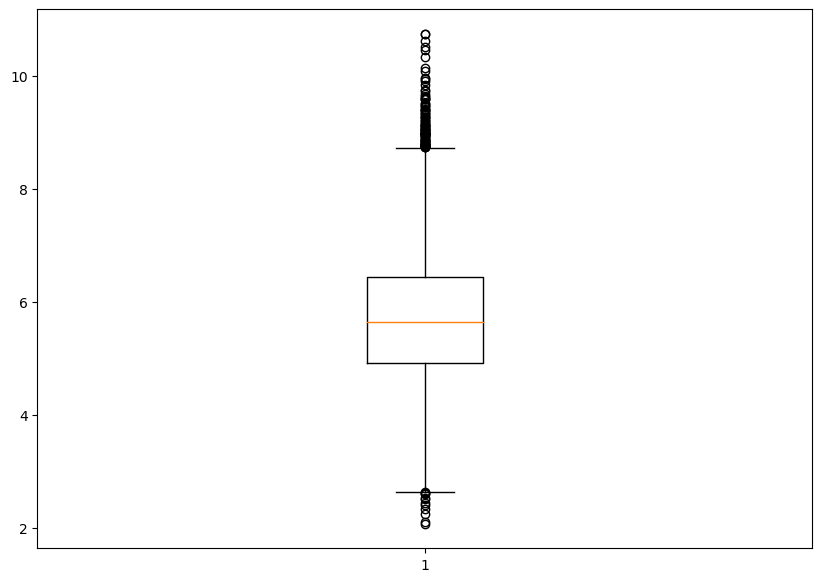

In [51]:
fig = plt.figure(figsize =(10, 7))
plt.boxplot(bk['cholesterol_0'])
plt.show()

In [52]:
bk['MET_activity'].describe()

count    10000.00000
mean      2640.81551
std       2678.40509
min          0.00000
25%        780.00000
50%       1775.00000
75%       3546.00000
max      19278.00000
Name: MET_activity, dtype: float64

**Mean**: The average MET activity level is approximately 2640.82. This number represents the average amount of physical activity, measured in METs, undertaken by the individuals in this dataset.\
**Standard Deviation**: The standard deviation is about 2678.41, indicating a high level of variability in MET activity levels among individuals. This suggests a wide range of physical activity levels, from very low to very high.\
**Minimum and Maximum**: The MET activity levels range from 0 to 19,278. The presence of 0 indicates no physical activity for some individuals, while the maximum value indicates extremely high levels of activity for others. And I do believe that there's potential outliers in this column since 1 MET is already a lowest value for sitting quietly all period. So there's not really possible to have the value like 0.\
**Quartiles**:
The 25th percentile is 780, meaning that 25% of individuals have MET activity levels below this, indicating low physical activity.\
The median (50th percentile) is 1775, suggesting that half of the individuals engage in a moderate level of physical activity.\
The 75th percentile is 3546, showing that 75% of individuals have MET activity levels below this, and 25% have higher levels, indicating higher physical activity.

In [53]:
desc_stat_analysis(bk,'MET_activity')


Statistics for MET_activity:
Variance: 7173853.823558758
Skewness: 2.0135499530782175
Kurtosis: 5.349561924570228


**Variance**:A high variance means that there's a large range in the MET activity levels of individuals. Some people are very inactive (low MET), while others are extremely active (high MET). This wide range suggests a diverse set of physical activity habits among the individuals in your dataset.\
**Skewness**:A value of 2.01 indicates a right-skewed or positively skewed distribution. This means that most people in your dataset have lower MET activity levels (less physical activity), but there are more people with very high activity levels than we would expect in a symmetrical distribution. In simple terms, a few individuals are exceptionally active compared to the rest.\
**Kurtosis**:A value of 5.35 suggests a leptokurtic distribution, which means the distribution has a sharper peak and fatter tails than a normal distribution. In this dataset, this implies that there are more individuals with either very high or very low MET activity levels than we would find in a typical, bell-shaped curve.

**Summary**:The MET activity data in this dataset shows a wide range of physical activity levels among individuals, with a tendency towards lower activity but with a significant presence of individuals engaging in very high levels of physical activity. The distribution is right-skewed with a relatively sharp peak, indicating that extreme values, particularly on the higher end, are more common than in a normal distribution.

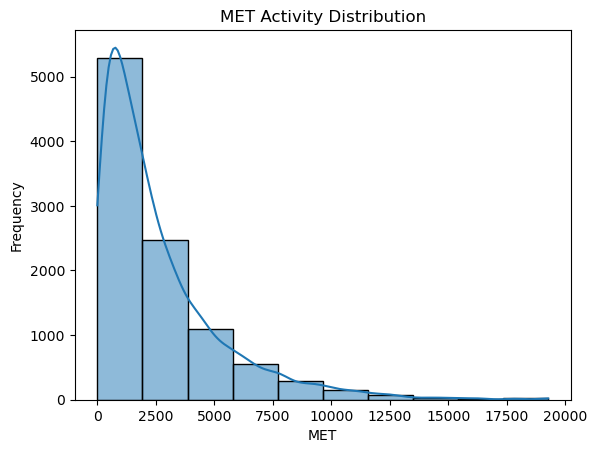

In [54]:
sb.histplot(bk['MET_activity'], kde=True, bins=10)
plt.title('MET Activity Distribution')
plt.xlabel('MET')
plt.ylabel('Frequency')

plt.show()

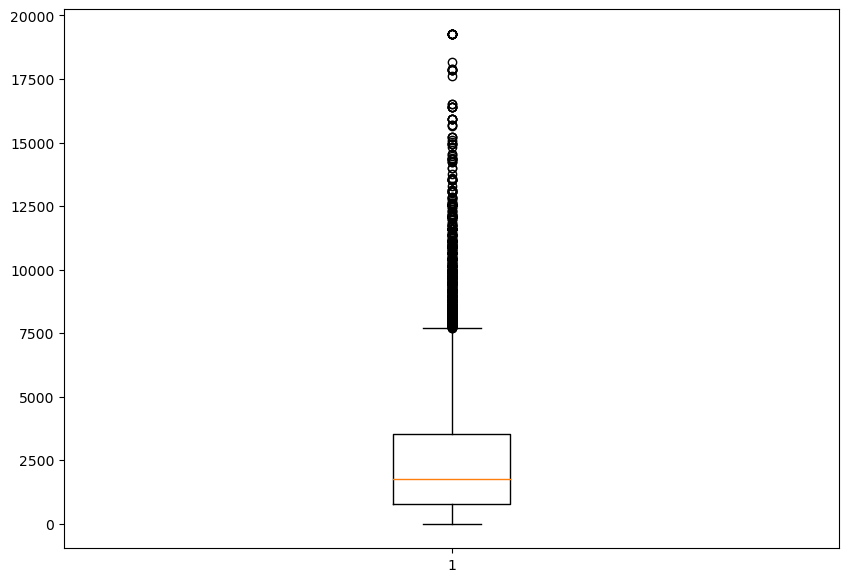

In [55]:
fig = plt.figure(figsize =(10, 7))
plt.boxplot(bk['MET_activity'])
plt.show()

**Smoking Status**:\
**0:Never / 1:Previous / 2:Current / 9:Prefer not to answer**

In [56]:
bk['smoking_status_0'].value_counts()

0    5444
1    3499
2    1028
9      29
Name: smoking_status_0, dtype: int64

In [58]:
bk['smoking_status_0'].value_counts(normalize=True)

0    0.5444
1    0.3499
2    0.1028
9    0.0029
Name: smoking_status_0, dtype: float64

**Summary**:\
The distribution of smoking status in the dataset shows that a significant majority of the individuals are either non-smokers or have quit smoking, with non-smokers being the largest group. Current smokers constitute a smaller fraction. This distribution provides valuable insights into the smoking habits and tendencies of the population in this study, which can be critical for research related to health outcomes and lifestyle behaviors.

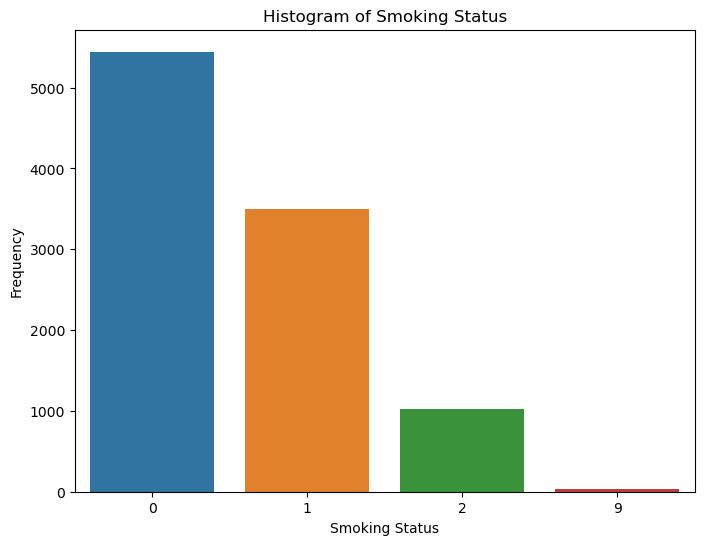

In [13]:
plt.figure(figsize=(8, 6))
sb.countplot(x='smoking_status_0', data=bk)
plt.title('Histogram of Smoking Status')
plt.xlabel('Smoking Status')
plt.ylabel('Frequency')
plt.show()

**Smoking Status**:\
**0:Never / 1:Previous / 2:Current / 9:Prefer not to answer**

In [59]:
bk['alcohol_status_0'].value_counts()

2    9247
0     387
1     362
9       4
Name: alcohol_status_0, dtype: int64

In [60]:
bk['alcohol_status_0'].value_counts(normalize=True)

2    0.9247
0    0.0387
1    0.0362
9    0.0004
Name: alcohol_status_0, dtype: float64

**Summary**:\
The distribution of Alcohol Satus showing that over 92% of population in this dataset have smoking habbit in this period of time. This unusual distribution suggests either a specific demographic or a unique population subset being studied, particularly considering the high prevalence of current smokers. This aspect is crucial for any health-related research or analysis, as it significantly impacts the interpretation of any associations or outcomes related to smoking.

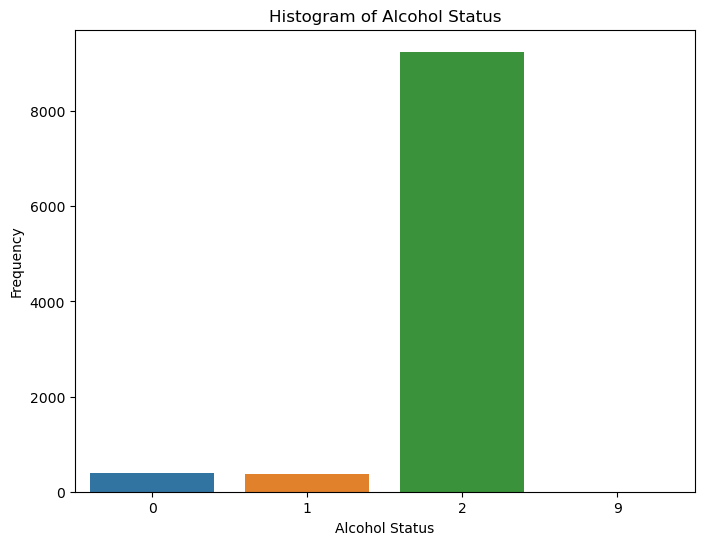

In [61]:
plt.figure(figsize=(8, 6))
sb.countplot(x='alcohol_status_0', data=bk)
plt.title('Histogram of Alcohol Status')
plt.xlabel('Alcohol Status')
plt.ylabel('Frequency')
plt.show()

In [69]:
def kruskal_wallis_test(data, factors, outcomes):
    test_results = {}
    for factor in factors:
        for outcome in outcomes:
            clean_data = data.dropna(subset=[factor, outcome])
            groups = [group.dropna().values for name, group in clean_data.groupby(outcome)[factor]]
            if len(groups) > 1:  
                stat, p = kruskal(*groups)
                test_results[(factor, outcome)] = (stat, p)
            else:
                test_results[(factor, outcome)] = (None, None)
    return test_results

In [70]:
lifestyle_factors = ['bmi_0', 'cholesterol_0', 'MET_activity', 'smoking_status_0', 'alcohol_status_0']
cardiovascular_outcomes = ['MI_all_outcome', 'stroke_all_outcome']

results = kruskal_wallis_test(bk, lifestyle_factors, cardiovascular_outcomes)
for (factor, outcome), (stat, p) in results.items():
    print(f"Kruskal-Wallis test for {factor} and {outcome}: Stat={stat}, p={p}")

Kruskal-Wallis test for bmi_0 and MI_all_outcome: Stat=81.34063265335102, p=1.899800767904825e-19
Kruskal-Wallis test for bmi_0 and stroke_all_outcome: Stat=22.71051918752446, p=1.8833404907706119e-06
Kruskal-Wallis test for cholesterol_0 and MI_all_outcome: Stat=99.68590647338611, p=1.7858756122998056e-23
Kruskal-Wallis test for cholesterol_0 and stroke_all_outcome: Stat=53.01426886794636, p=3.311341267192184e-13
Kruskal-Wallis test for MET_activity and MI_all_outcome: Stat=3.029245379995845, p=0.08177604158872623
Kruskal-Wallis test for MET_activity and stroke_all_outcome: Stat=0.7288282189047934, p=0.3932632722129613
Kruskal-Wallis test for smoking_status_0 and MI_all_outcome: Stat=32.952319099824564, p=9.444701598629804e-09
Kruskal-Wallis test for smoking_status_0 and stroke_all_outcome: Stat=7.478435674420893, p=0.00624422989724107
Kruskal-Wallis test for alcohol_status_0 and MI_all_outcome: Stat=8.688777109945883, p=0.0032017537130229327
Kruskal-Wallis test for alcohol_status_0 a

### Bivariate Analysis
**Details**:To examine the relationship between each lifestyle factor and the occurrence of cardiovascular diseases.

**Null Hypothesis(H0)**: There's no difference between two variables.\
**Alternative Hypothesis(H1)**: There's significant difference between two variables.

**BMI and Cardiovascular**:
- **MI**: There is a statistically significant difference in BMI among groups with different MI outcomes. The very low p-value (p < 1e-19) suggests strong evidence against the null hypothesis, indicating that BMI could be an influential factor in MI outcomes.
- **Stroke**:BMI shows a statistically significant association with stroke outcomes, with a p-value (p < 1e-6) that indicates a strong relationship between BMI and the occurrence of strokes.\
**Cholesterol and Cardiovascular**:
- **MI**:Cholesterol levels have a statistically significant association with MI outcomes, with an even lower p-value (p < 1e-23) than BMI, suggesting a very strong influence of cholesterol levels on MI outcomes.
- **Stroke**:Cholesterol also shows a significant association with stroke outcomes, with a p-value (p < 1e-13), reaffirming its role as a critical factor in stroke events.\
**MET activity and Cardiovascular**:
- **MI**:Since the p-value is greater than 0.05, meaing that we have no enough evidence to reject the H0, meaning that MET activity may has no strong relation with MI outcomes.
- **Stroke**: Similarly, we do not have enought evidence to reject the null hypothesis that there's significant association between two variables with p-value over 0.05(p-value= 0.3932632722129613), meaning that the MET activity might has no strong relation with stroke and suggesting MET activity might not be the significant factor for determining the risk of stroke.\
**Smoking status and Cardiovascular**:
- **MI**:Smoking status shows a significant association with MI outcomes (p < 1e-8), indicating that smoking could be a significant risk factor for myocardial infarction.
- **Stroke**: There is a significant association between smoking status and stroke outcomes (p = 0.0062), which suggests smoking status also plays a role in the occurrence of strokes. But we can aware that the relationship is less pronounced than with MI.\
**Alcohol status and Cardiovascular**:
- **MI**:With statistically significant association with MI outcomes (p = 0.0032), showing the relationship between alcohol consumption habits and myocardial infarction.
- **Stroke**: Alcohol status also shows a significant relationship with stroke outcomes (p = 0.00029), bringing up the potential influence of alcohol consumption on the risk of stroke.

**Summary**:\
BMI and cholesterol levels have a strong association with both MI and stroke outcomes. Smoking status is significantly associated with both MI and stroke, while alcohol status is significantly associated with both outcomes, though with less extreme p-values. MET activity levels didn't show a significant association with either cardiovascular outcome in this dataset. These results highlight the importance and relationship of these lifestyle factors in cardiovascular health.

## Multivariate Logistic Regression
**Details**:To assess the impact of multiple lifestyle factors on the likelihood of developing cardiovascular diseases, adjusting for potential confounders like age and sex.

In [71]:
bk['sex_num']=bk['sex'].map({'M':1,'F':0})

In [79]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
X=bk[['bmi_0', 'cholesterol_0', 'MET_activity', 'smoking_status_0', 'alcohol_status_0','age','sex_num']]
X = sm.add_constant(X)
vif_data = pd.DataFrame() 
vif_data["feature"] = X.columns 
vif_data["VIF"] = [variance_inflation_factor(X.values, i) 
                          for i in range(len(X.columns))] 
  
print(vif_data)

            feature         VIF
0             const  127.538590
1             bmi_0    1.020883
2     cholesterol_0    1.038007
3      MET_activity    1.011365
4  smoking_status_0    1.013167
5  alcohol_status_0    1.012223
6               age    1.007695
7           sex_num    1.055002


The Variance Inflation Factor is a measure that can help to identify the presence of multicollinearity in the set of predictor variables in a regression model before we do the multivariate logistic regression. 

**Result**:
All other variables (bmi_0, cholesterol_0, MET_activity, smoking_status_0, alcohol_status_0, age, sex_num) have VIF values very close to 1, far below the threshold of 5 or 10, suggesting that there is no significant multicollinearity between these predictors in your model and impliing that each independent variable provides unique information that is not redundantly encoded by the other variables.\
With these low VIF values, we now are reasonable to proceed with multivariate logistic regression analysis without concerns about multicollinearity affecting the estimation of coefficients.

In [81]:
y_MI=bk['MI_all_outcome']
model_mi = sm.Logit(y_MI, X).fit()
model_mi.summary()

Optimization terminated successfully.
         Current function value: 0.185757
         Iterations 8


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:         MI_all_outcome   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9992
Method:                           MLE   Df Model:                            7
Date:                Fri, 17 Nov 2023   Pseudo R-squ.:                  0.1050
Time:                        00:35:26   Log-Likelihood:                -1857.6
converged:                       True   LL-Null:                       -2075.4
Covariance Type:            nonrobust   LLR p-value:                 5.139e-90
====================================================================================
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -7.3805      0.599    -12.319      0.000      -8.555      -6.206
bmi_0                0.0581      0.009      6.341      0.000       0.040       0.076
cholesterol_0       -0.2854      0.042     -6.867      0.000      -0.367      -0.204
MET_activity      5.363e-06   1.68e-05      0.319      0.750   -2.76e-05    3.84e-05
smoking_status_0     0.1033      0.047      2.206      0.027       0.012       0.195
alcohol_status_0    -0.1518      0.098     -1.546      0.122      -0.344       0.041
age                  0.0684      0.007     10.511      0.000       0.056       0.081
sex_num              1.0592      0.107      9.862      0.000       0.849       1.270
====================================================================================
"""

**Pseudo R-squared (0.1050)**:  
A value of 0.1050 suggests the model explains some, but not all, of the variability of the outcome.\
**LLR p-value (5.139e-90)**: This p-value tests the null hypothesis that all of the model coefficients are equal to zero , which in other words, that none of the predictors have an effect. The very small p-value here suggests that the model as a whole is statistically significant.\

- **Coefficients**:
    - **Const**: The negative coef of Constant meaning that under the circumstance that all other variables are 0, the probability of MI occurs is low.
    - **BMI**: For each unit increase in BMI, the log odds of MI increases by 0.0581. This is significant (p < 0.000), suggesting a higher BMI is associated with a higher probability of MI.
    - **Cholesterol**: The negative coefficient (-0.2854) that is significant (p < 0.000) indicates that higher cholesterol levels are associated with a lower probability of MI. However this result is against the common sense we know about the relation between Cholesterol and MI, indicating a further investigation on this is needed.
    - **MET activity**: With the coefficient close to zero and not statistically significant (p = 0.750), we can say there's no clear association between MET activity levels and the probability of MI.
    - **Smoking Status**: With the positive coef (0.1033) and statistically significant (p-value=0.027), indicating that the smoker and previous smoker have higher probability of MI occurs than non-smokers.
    - **Alcohol Status**: The negative coefficient (-0.1518) is not statistically significant (p = 0.122), suggesting there's no clear association between alcohol status and MI within this model.(I knew it!)
    - **Age**: With the postive coef(0.0684), we can say the age increases the probability of MI.
    - **Sex**: The coefficient (1.0592) is positive and significant (p < 0.000), indicating that being male (since male is coded as 1) is associated with a higher probability of MI compared to being female. We might need a further investigation on this result since there're many articles and papers proving the female has higher probability.
    
**Summary**:
the model suggests that higher BMI, being a smoker, and being older are associated with higher odds of myocardial infarction, while the results for cholesterol levels and gender may require further investigation. MET activity and alcohol status do not show a significant association with MI in this model. 


In [82]:
y_STR= bk['stroke_all_outcome']
model_str = sm.Logit(y_STR, X).fit()
model_str.summary()

Optimization terminated successfully.
         Current function value: 0.132697
         Iterations 8


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:     stroke_all_outcome   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9992
Method:                           MLE   Df Model:                            7
Date:                Fri, 17 Nov 2023   Pseudo R-squ.:                 0.06976
Time:                        00:36:12   Log-Likelihood:                -1327.0
converged:                       True   LL-Null:                       -1426.5
Covariance Type:            nonrobust   LLR p-value:                 1.848e-39
====================================================================================
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -7.4717      0.743    -10.060      0.000      -8.927      -6.016
bmi_0                0.0433      0.011      3.884      0.000       0.021       0.065
cholesterol_0       -0.2850      0.052     -5.490      0.000      -0.387      -0.183
MET_activity     -2.939e-06   2.19e-05     -0.134      0.893   -4.59e-05       4e-05
smoking_status_0     0.0758      0.060      1.262      0.207      -0.042       0.193
alcohol_status_0    -0.2898      0.108     -2.681      0.007      -0.502      -0.078
age                  0.0820      0.008      9.668      0.000       0.065       0.099
sex_num              0.2148      0.122      1.759      0.079      -0.025       0.454
====================================================================================
"""

**Pseudo R-squared (0.06976)**: The value of 0.06976 suggests the model has modest explanatory power.\
**LLR p-value (1.848e-39)**: This very small p-value suggests that the model as a whole is statistically significant.\
- **Coefficients**:
    - **Const**: The negative coef of Constant meaning that under the circumstance that all other variables are 0, the probability of Stroke occurs is low.
    - **BMI**: For each unit increase in BMI, the log odds of MI increases by 0.0433. This is significant (p < 0.011), suggesting a higher BMI is associated with a higher probability of Stroke.
    - **Cholesterol**: The negative coefficient (-0.2850) that is significant (p < 0.000) indicates that higher cholesterol levels are associated with a lower probability of Stroke. Simliar to issue with MI, this result is against the common sense we know about the relation between Cholesterol and cardiovascular diease, indicating a further investigation on this is needed.
    - **MET activity**: Also simliar to MI, the coefficient is very small and not statistically significant (p = 0.893), indicating that there is no strong evidence of an association between MET activity and the likelihood of having a stroke.
    - **Smoking Status**: The coefficient is positive but not statistically significant (p = 0.207), suggesting that there is no strong evidence of an association between smoking status and stroke outcomes in this dataset.
    - **Alcohol Status**: The negative and significant coefficient (p = 0.007) suggests that higher alcohol status is associated with lower log-odds of having a stroke. This required a deeper investigation.
    - **Age**: With the postive coef(0.0820), we can say the age increases the probability of Stroke.
    - **Sex**: The coefficient is positive, indicating that males (since male is coded as 1) might have higher log-odds of having a stroke compared to females, but this result is not statistically significant (p = 0.079), suggesting that it may not be a strong effect in this dataset. We might need a further investigation on this result since there're many articles and papers proving the female has higher probability on cardiovascular.
    
**Summary**:
The model suggests that BMI and age are significant predictors of stroke occurrence, with higher values associated with an increased likelihood of stroke. Cholesterol is inversely associated with stroke, which is an unusual finding. Alcohol consumption is associated with a decreased likelihood of stroke, while smoking and sex do not show a strong statistical association with stroke outcomes. 

## Correlation Analysis
**Details**:To explore the interrelationships among the lifestyle factors themselves.

In [18]:
bk_for_boxplot.drop(columns='ID',inplace=True)

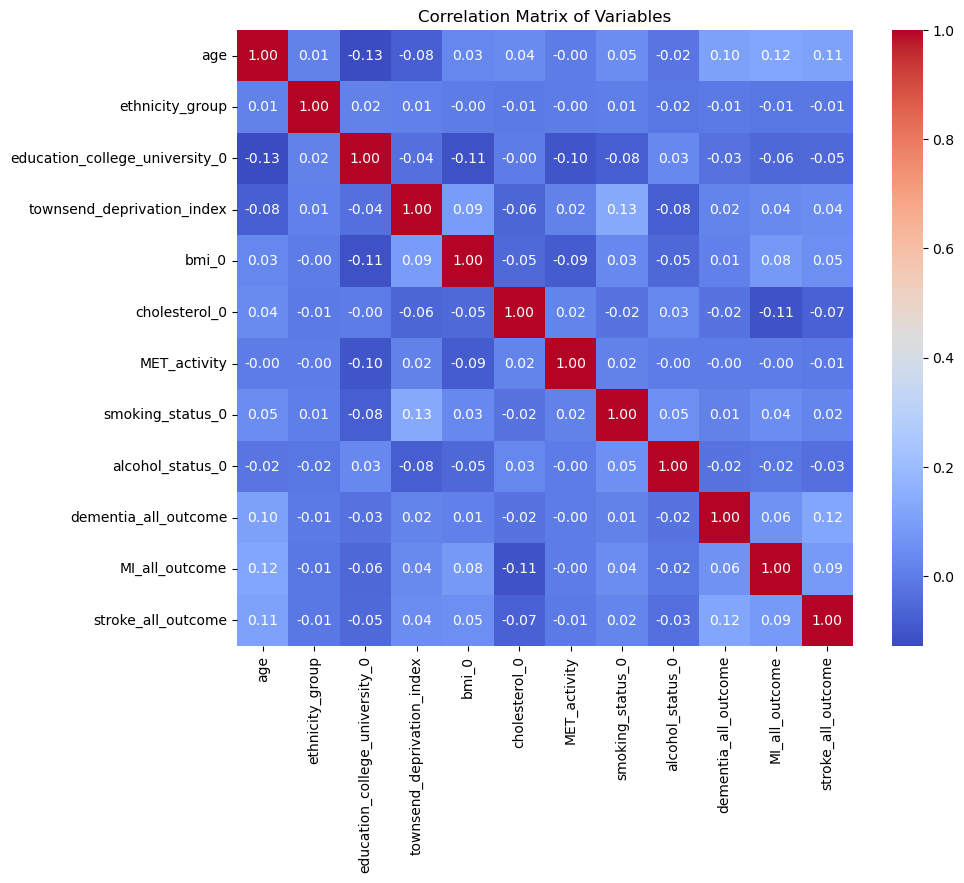

In [83]:
correlation_matrix = bk_for_boxplot.corr()
plt.figure(figsize=(10, 8))
sb.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Matrix of Variables')
plt.show()

In [84]:
correlation_matrix 

,age,ethnicity_group,education_college_university_0,townsend_deprivation_index,bmi_0,cholesterol_0,MET_activity,smoking_status_0,alcohol_status_0,dementia_all_outcome,MI_all_outcome,stroke_all_outcome
age,1.000000,0.014165,-0.127977,-0.078372,0.029821,0.040588,-0.001337,0.045215,-0.021354,0.103611,0.121358,0.105940
ethnicity_group,0.014165,1.000000,0.016068,0.010595,-0.002757,-0.005835,-0.000954,0.007603,-0.016920,-0.007277,-0.014215,-0.011109
education_college_university_0,-0.127977,0.016068,1.000000,-0.035135,-0.110707,-0.003890,-0.101565,-0.081662,0.032921,-0.029772,-0.055501,-0.051904
townsend_deprivation_index,-0.078372,0.010595,-0.035135,1.000000,0.088139,-0.059503,0.016559,0.133203,-0.080483,0.019329,0.038337,0.043952
bmi_0,0.029821,-0.002757,-0.110707,0.088139,1.000000,-0.050018,-0.085523,0.031372,-0.053975,0.011305,0.080122,0.051381
cholesterol_0,0.040588,-0.005835,-0.003890,-0.059503,-0.050018,1.000000,0.019722,-0.023433,0.030176,-0.024487,-0.108227,-0.070766
MET_activity,-0.001337,-0.000954,-0.101565,0.016559,-0.085523,0.019722,1.000000,0.016257,-0.004029,-0.000824,-0.000298,-0.005739
smoking_status_0,0.045215,0.007603,-0.081662,0.133203,0.031372,-0.023433,0.016257,1.000000,0.052998,0.014748,0.044635,0.022418
alcohol_status_0,-0.021354,-0.016920,0.032921,-0.080483,-0.053975,0.030176,-0.004029,0.052998,1.000000,-0.022703,-0.015187,-0.033292
dementia_all_outcome,0.103611,-0.007277,-0.029772,0.019329,0.011305,-0.024487,-0.000824,0.014748,-0.022703,1.000000,0.061218,0.120352


## Conclusion
**Overview**:\
This study aimed to understand the influence of lifestyle factors on the risk of cardiovascular diseases, specifically focusing on myocardial infarction and stroke. Key lifestyle factors considered were smoking, alcohol consumption, physical activity (MET activity), along with biometric indicators such as BMI and cholesterol levels. The analysis, grounded in descriptive and bivariate statistics, along with multivariate logistic regression, offers some observations:
- **Age and Gender**: The dataset mainly included middle-aged to older adults, with a balanced gender representation. This demographic profile is critical as it aligns with the age group generally at higher risk for cardiovascular disease. Hewever, we found that either for MI or Stroke, the research indicates that males might have higher probability for risk of cardiovascular disease compared to females, this finding might be conflict with many research that female have higher probability for CD.
- **BMI**: The findings suggest a population trend towards overweight, with a significant number of individuals having BMI values in the overweight or obese range. Given the established link between higher BMI and increased CD risk, this observation might be noteworthy.
- **Cholesterol**: The distribution showed moderate variability with a slight skew towards higher levels. Considering the known risks associated with high cholesterol, this finding is significant for understanding the cardiovascular risk profile of the study population.
- **MET Activity**: After the study, the result shows that there's no significant association between the MET activity and CD, which is an interesting finding, since the generally accepted benefits of physical activity for heart health.
- **Smoking and Alcohol**: Smoking status was significantly associated with both MI and stroke, underscoring its role as a critical risk factor for CD. In contrast, alcohol status presented a complex picture, with some evidence suggesting it may influence the risk of stroke and MI, though the relationships were not uniformly strong.
- **Multivariate Logistic Regression Analysis**:This analysis find that higher BMI, smoking, and age were associated with a higher risk of MI. Surprisingly, cholesterol levels showed an inverse association with MI and stroke risk, warranting further investigation. Gender differences in CD risk were also noted, with males showing higher odds of MI, contradicting some previous studies that suggest higher risk in females.
- **Limitations and Further Research**: I think if there's more features like time variable can help to do the Survivor Analysis.

**Question Addressing**:\
The study answers the research question by displaying that lifestyle factors like smoking status and BMI significantly contribute to CD risk, while the role of physical activity (MET) and alcohol consumption is more complex and less definitive. These findings contribute valuable insights to the broader understanding of how lifestyle choices impact cardiovascular health.